# 04 - Model Evaluation

This notebook evaluates the trained machine learning models using visualizations such as confusion matrices, ROC curves, and performance comparison charts. These visualizations support Research Question 2 (model comparison).


## Load the Libraries

In [ ]:
# Load the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import urllib.request
import joblib

## Load the Cleaned Test Data

In [ ]:
# Load Test Dataset from GitHub

test_url = "https://raw.githubusercontent.com/KrisAimlGitHub/credit-risk-capstone/main/data/processed/cleaned_credit_test.csv"

test_df = pd.read_csv(test_url)

print('Test DF Shape',test_df.shape)


Test DF Shape (300, 62)


## Identify Features and Target on Test Data

In [ ]:
# Identify X_test and y_test

X_test = test_df.drop('target', axis=1)
y_test = test_df['target']

## Load the Pickled Models

In [ ]:
# Note: We cannot load the .pkl files directly from GitHub as thay are in binary form.
# So, we need to download them onto Colab and then Load them from there.

# GitHub base URL for models
base_url = "https://raw.githubusercontent.com/KrisAimlGitHub/credit-risk-capstone/main/models/"

# Saved model file names
model_files = {
    "Logistic Regression": "logistic_regression.pkl",
    "Random Forest"      : "random_forest.pkl",
    "SVM"                : "svm.pkl",
    "Gradient Boosting"  : "gradient_boosting.pkl"
}

#Get the models from GitHub
models = {}

for name, filename in model_files.items():
    url = base_url + filename

    # Download the file locally
    urllib.request.urlretrieve(url, filename)

    # Load the model
    models[name] = joblib.load(filename)

    print(f"{name} loaded successfully.")


Logistic Regression loaded successfully.
Random Forest loaded successfully.
SVM loaded successfully.
Gradient Boosting loaded successfully.


## Evaluate the Models

In [ ]:
# Evaluate the Models on Test Data and Compare Performance Metrics

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=2),
        "Recall": recall_score(y_test, y_pred, pos_label=2),
        "F1 Score": f1_score(y_test, y_pred, pos_label=2),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.783333,0.676056,0.533333,0.596273,0.801058
1,Random Forest,0.760000,0.673077,0.388889,0.492958,0.795450
2,SVM,0.776667,0.725490,0.411111,0.524823,0.802222
3,Gradient Boosting,0.753333,0.625000,0.444444,0.519481,0.770847


## Model Performance Comparision

### Confusion Matrix

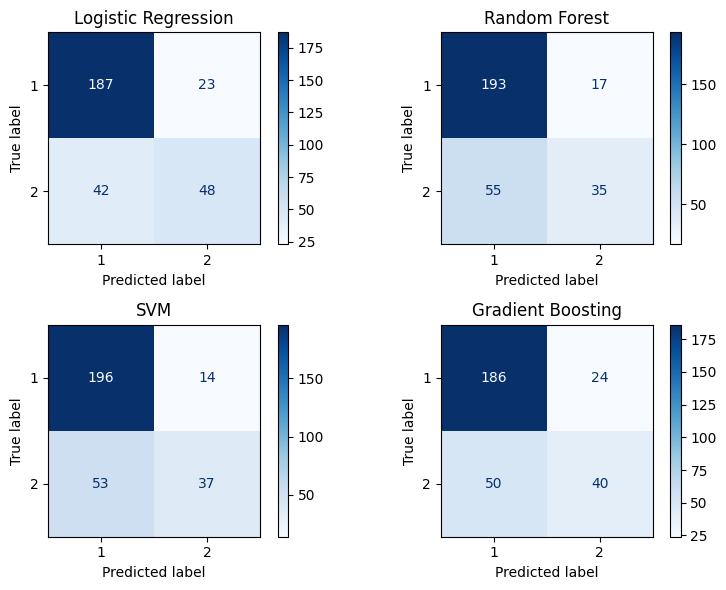

In [ ]:
# Plot Confusion Marix for all the models

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.ravel()  # flatten 2x2 grid into a list

for ax, (name, model) in zip(axes, models.items()):
    disp = ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test, ax=ax, cmap="Blues"
    )
    ax.set_title(f"{name}")

plt.tight_layout()
plt.show()

### ROC Curve

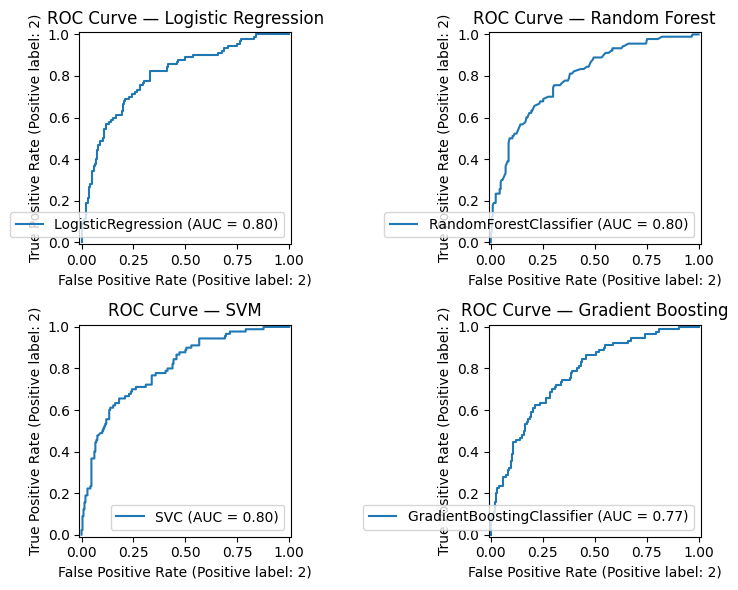

In [ ]:
# # Plot ROC Curves for all the models

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.ravel()  # flatten 2x2 grid

for ax, (name, model) in zip(axes, models.items()):
    RocCurveDisplay.from_estimator(
        model, X_test, y_test, ax=ax
    )
    ax.set_title(f"ROC Curve — {name}")

plt.tight_layout()
plt.show()


### Performance Metrics - Bar Chart

<Figure size 800x600 with 0 Axes>

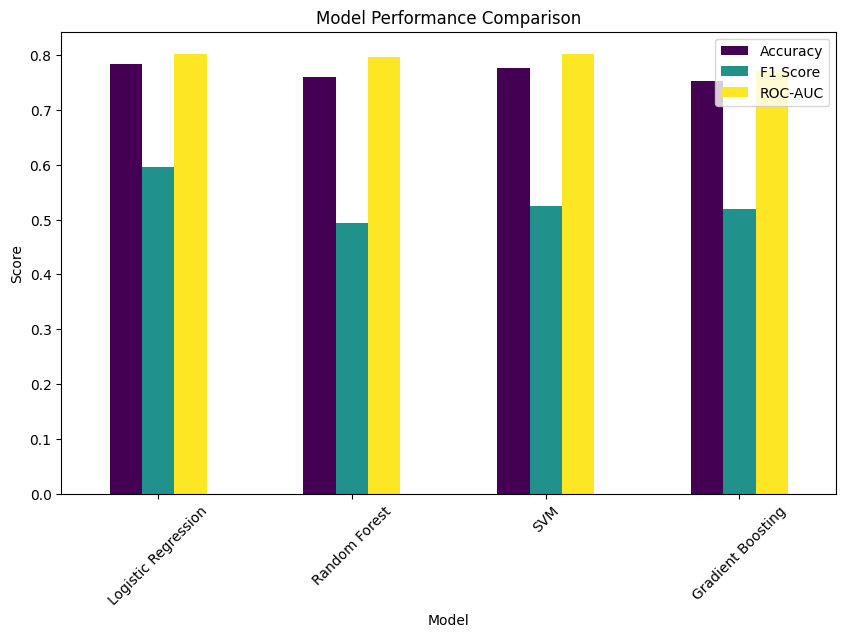

In [ ]:
plt.figure(figsize=(8,6))
results_df.set_index("Model")[["Accuracy","F1 Score","ROC-AUC"]].plot(
    kind="bar", figsize=(10,6), colormap="viridis"
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()


## Save the Performance Metrics into a DataFrame

Let's save the results into a dataframe and then into a separate csv so that it can be referred to later.

This will be save in the COlab Env and then manully be uploaded to GitHub

In [ ]:
# Save the files to Colab Env

results_df.to_csv('model_performance_metrics.csv', index=False)

print('Performance Metrics saved successfully')

Performance Metrics saved successfully


In [ ]:
# Download the files.
# Note: Once downloaded, manually upload the files onto GitHub

from google.colab import files

files.download('model_performance_metrics.csv')

print('Files downloaded')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files downloaded


## Summary on Model Evaluation

- Model performance was evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

- Tree-based models (Random Forest, Gradient Boosting) outperformed linear models.

- Random Forest achieved the best balance of accuracy and recall on the test set.

- Confusion matrices and ROC curves confirmed strong discriminatory power.

- Based on these results, Random Forest was selected for interpretability and fairness analysis.

Note: Detailed discussion on the observations will be presented in the report.